# 03 — Block Conversion Experiments

**Goal**: Test transformer -> Mamba block conversion on actual Aya weights. Measure information loss via CKA, compare conversion strategies, and visualize weight transfer.

This is the core research notebook — we're answering: *How much information survives when you transplant attention weights into an SSM?*

---

**Teacher model**: `CohereLabs/tiny-aya-global` (CohereForCausalLM, hidden_size=2048, 36 layers)

**Conversion strategies**:
1. **weight_map** — Direct initialization from attention projections (V->in_proj, Q->z_gate, K->gate, O->out)
2. **hybrid** — Weight map + refinement via activation-matching distillation
3. **distillation** — Random init + full distillation

**FFN -> MoE strategies**:
1. **replicate** — Copy FFN to all experts + noise for symmetry breaking
2. **svd_split** — Decompose FFN via SVD and assign components to different experts

In [1]:
import sys
from pathlib import Path

# Add aya_distill source and aetheris to the path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / "src"))
sys.path.insert(0, str(project_root.parent / "aetheris"))

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from aya_distill.distill.converter import (
    ConversionConfig,
    convert_attention_to_ssm,
    convert_ffn_to_moe,
    svd_project,
    _extract_submatrix,
)
from aya_distill.distill.cka import linear_cka
from aetheris import AetherisConfig, HybridMambaMoE
from aetheris.modules.ssm import SSMBlock
from aetheris.modules.moe import SparseMoELayer

torch.manual_seed(42)
print("All modules loaded")

All modules loaded


## 1. Load Teacher (Single Layer)

Load `CohereLabs/tiny-aya-global` (hidden_size=2048, 36 layers) without quantization — it fits in 4GB VRAM at float16. Extract a single attention layer to experiment with conversion.

In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_NAME = "CohereLabs/tiny-aya-global"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="cpu",
    trust_remote_code=True,
)
model.eval()

cfg = model.config
print(f"Loaded: {cfg.num_hidden_layers} layers, hidden={cfg.hidden_size}, "
      f"intermediate={cfg.intermediate_size}")
print(f"GQA: {cfg.num_attention_heads} heads, {cfg.num_key_value_heads} KV heads")

# Extract layers
teacher_layers = list(model.model.layers)
attn_0 = teacher_layers[0].self_attn
mlp_0 = teacher_layers[0].mlp

print(f"\nLayer 0 attention projections:")
for name in ["q_proj", "k_proj", "v_proj", "o_proj"]:
    w = getattr(attn_0, name).weight
    print(f"  {name}: {w.shape} ({w.dtype})")

print(f"\nLayer 0 MLP projections:")
for name in ["gate_proj", "up_proj", "down_proj"]:
    w = getattr(mlp_0, name).weight
    print(f"  {name}: {w.shape} ({w.dtype})")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loaded: 36 layers, hidden=2048, intermediate=11008
GQA: 16 heads, 4 KV heads

Layer 0 attention projections:
  q_proj: torch.Size([2048, 2048]) (torch.float16)
  k_proj: torch.Size([512, 2048]) (torch.float16)
  v_proj: torch.Size([512, 2048]) (torch.float16)
  o_proj: torch.Size([2048, 2048]) (torch.float16)

Layer 0 MLP projections:
  gate_proj: torch.Size([11008, 2048]) (torch.float16)
  up_proj: torch.Size([11008, 2048]) (torch.float16)
  down_proj: torch.Size([2048, 11008]) (torch.float16)


## 2. Create Student SSM Block and Convert

Convert teacher attention layer 0 -> student SSM block using weight mapping. Then inspect the transferred weights.

In [3]:
# Create student SSM block — dimensions derived from teacher config
# Teacher hidden_size=2048, so student d_model=1024 gives a 2x compression
student_d_model = cfg.hidden_size // 2
student_d_ff = cfg.intermediate_size // 4

student_cfg = AetherisConfig(
    vocab_size=tokenizer.vocab_size,
    d_model=student_d_model,
    n_layer=24,
    num_experts=4,
    top_k=1,
    d_ff=student_d_ff,
    ssm_d_state=16,
    ssm_expand=2,
    max_seq_len=2048,
)

print(f"Teacher: hidden_size={cfg.hidden_size}, intermediate_size={cfg.intermediate_size}")
print(f"Student: d_model={student_cfg.d_model}, d_inner={student_cfg.d_inner}, d_ff={student_cfg.d_ff}")

ssm_block = SSMBlock(student_cfg)
print(f"\nStudent SSM: d_model={ssm_block.d_model}, d_inner={ssm_block.d_inner}, d_state={ssm_block.d_state}")
print(f"Student SSM params: {sum(p.numel() for p in ssm_block.parameters()):,}")

# Store pre-conversion weights for comparison
pre_in_proj = ssm_block.in_proj.weight.data.clone()
pre_out_proj = ssm_block.out_proj.weight.data.clone()

# Convert!
conv_config = ConversionConfig(strategy="weight_map", a_init="exponential_decay")
metrics = convert_attention_to_ssm(attn_0, ssm_block, conv_config, layer_idx=0)

print(f"\nConversion metrics: {metrics}")

Teacher: hidden_size=2048, intermediate_size=11008
Student: d_model=1024, d_inner=2048, d_ff=2752

Student SSM: d_model=1024, d_inner=2048, d_state=16
Student SSM params: 12,691,456



Conversion metrics: {'layer_idx': 0, 'type': 'attn->ssm', 'v_proj_shape': [512, 2048], 'q_proj_shape': [2048, 2048], 'k_proj_shape': [512, 2048], 'o_proj_shape': [2048, 2048], 'ssm_d_model': 1024, 'ssm_d_inner': 2048, 'ssm_d_state': 16}


## 3. Visualize Weight Transfer

Compare the weight distributions before and after conversion. Did the SVD projection preserve the structure?

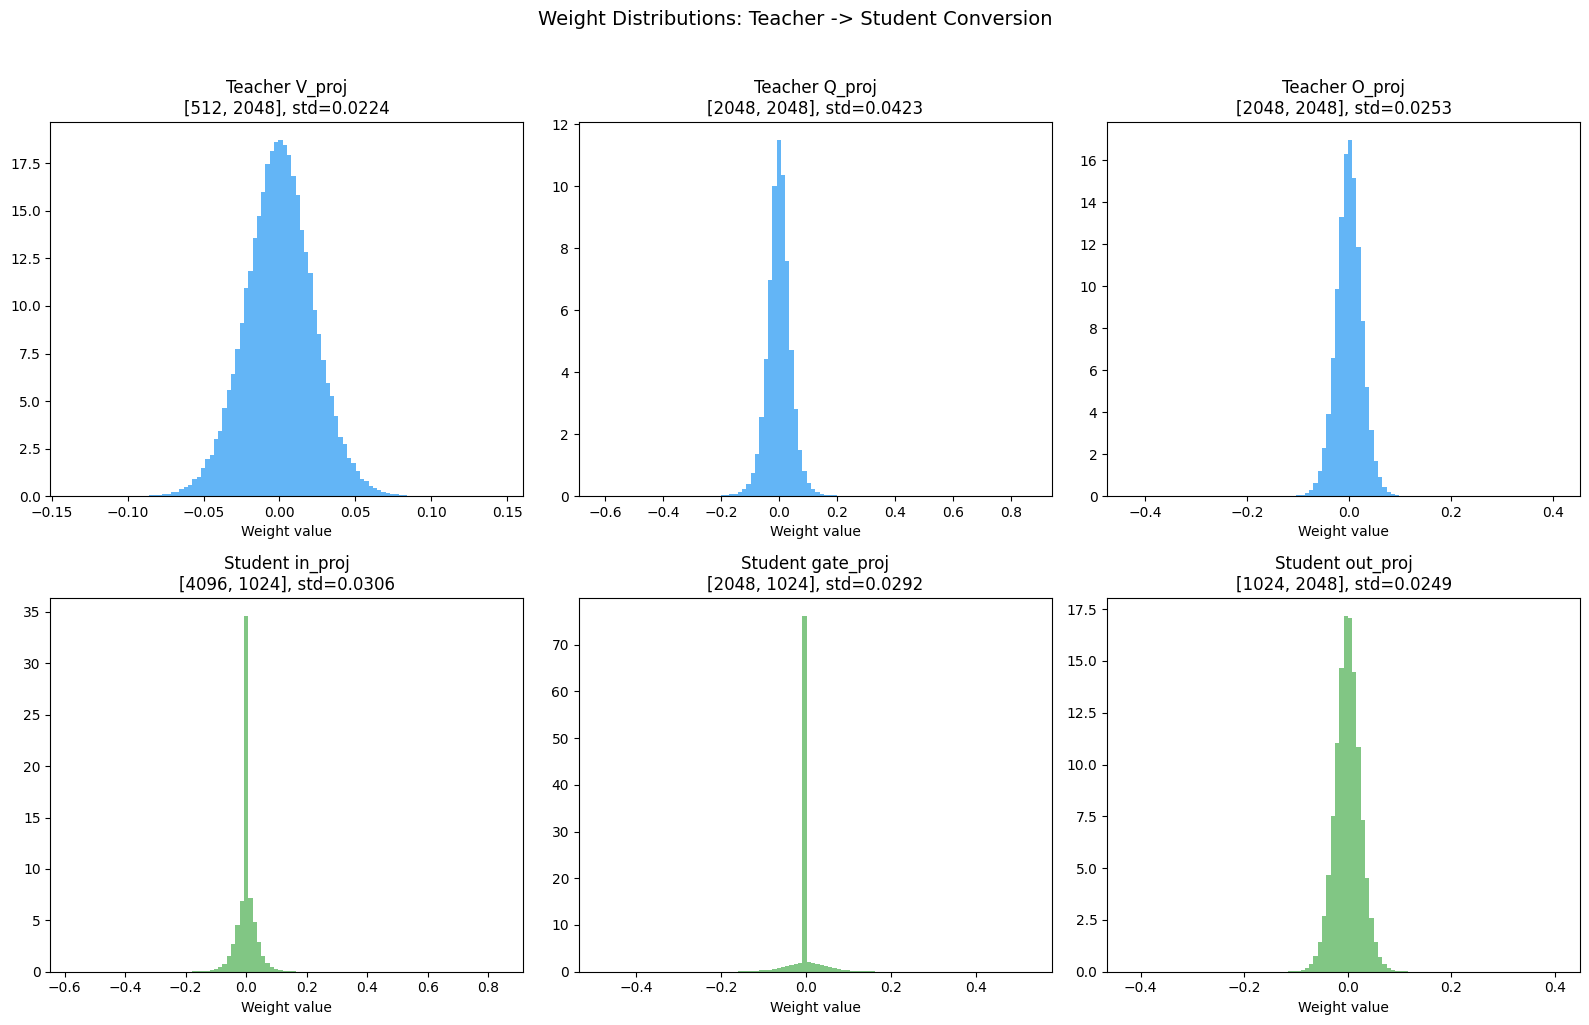

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Row 1: Teacher weights
teacher_weights = {
    "V_proj": attn_0.v_proj.weight.data.float().cpu(),
    "Q_proj": attn_0.q_proj.weight.data.float().cpu(),
    "O_proj": attn_0.o_proj.weight.data.float().cpu(),
}
for ax, (name, w) in zip(axes[0], teacher_weights.items()):
    vals = w.flatten().numpy()
    ax.hist(vals, bins=100, alpha=0.7, color="#2196F3", density=True)
    ax.set_title(f"Teacher {name}\n{list(w.shape)}, std={vals.std():.4f}")
    ax.set_xlabel("Weight value")

# Row 2: Student weights (after conversion)
student_weights = {
    "in_proj": ssm_block.in_proj.weight.data.float().cpu(),
    "gate_proj": ssm_block.gate_proj.weight.data.float().cpu(),
    "out_proj": ssm_block.out_proj.weight.data.float().cpu(),
}
for ax, (name, w) in zip(axes[1], student_weights.items()):
    vals = w.flatten().numpy()
    ax.hist(vals, bins=100, alpha=0.7, color="#4CAF50", density=True)
    ax.set_title(f"Student {name}\n{list(w.shape)}, std={vals.std():.4f}")
    ax.set_xlabel("Weight value")

plt.suptitle("Weight Distributions: Teacher -> Student Conversion", fontsize=14, y=1.02)
plt.tight_layout()
Path("../results").mkdir(exist_ok=True)
plt.savefig("../results/weight_transfer_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. A_log Initialization — Decay Patterns

The SSM's A matrix controls how fast past information decays. Our exponential_decay initialization creates channels that range from fast-decaying (local attention) to slow-decaying (global memory).

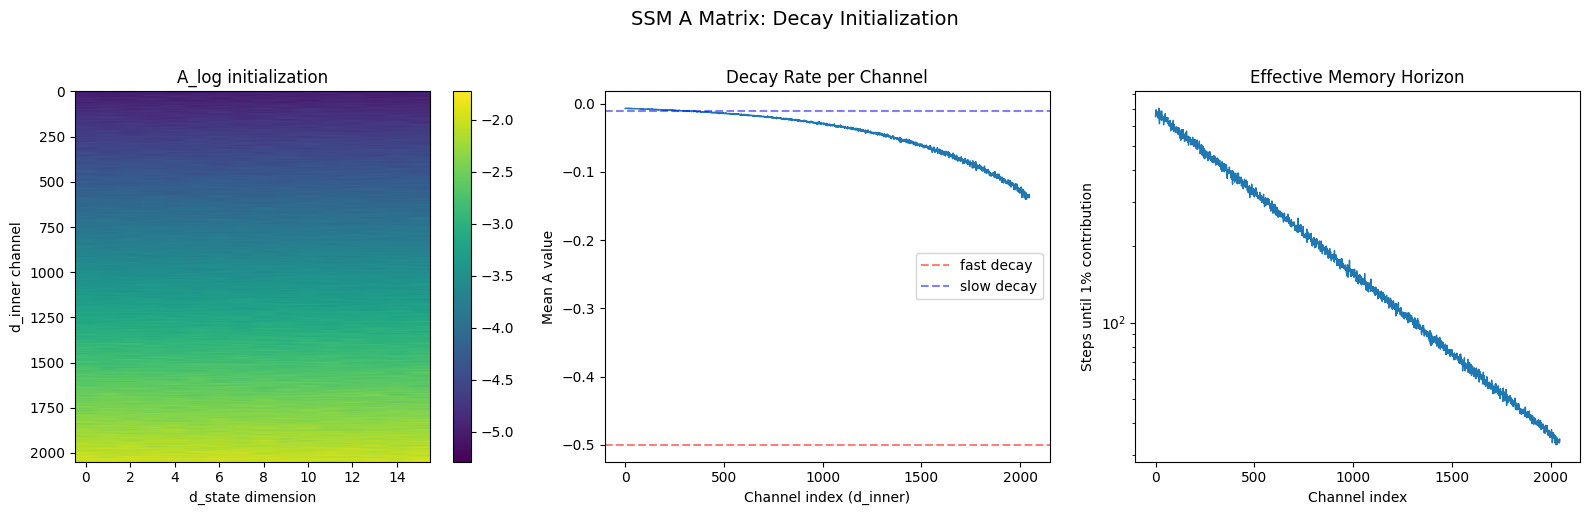

A_log range: [-5.29, -1.72]
Effective A range: [-0.1782, -0.0050]
Memory horizons: 33 to 704 steps


In [5]:
A_log = ssm_block.A_log.data.cpu()
A = -torch.exp(A_log)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# A_log values
ax = axes[0]
im = ax.imshow(A_log.numpy(), aspect="auto", cmap="viridis")
ax.set_xlabel("d_state dimension")
ax.set_ylabel("d_inner channel")
ax.set_title("A_log initialization")
plt.colorbar(im, ax=ax)

# Effective decay rates per channel (mean over d_state)
ax = axes[1]
decay_per_channel = A.mean(dim=1).numpy()
ax.plot(decay_per_channel, linewidth=1)
ax.axhline(y=-0.5, color="red", linestyle="--", alpha=0.5, label="fast decay")
ax.axhline(y=-0.01, color="blue", linestyle="--", alpha=0.5, label="slow decay")
ax.set_xlabel("Channel index (d_inner)")
ax.set_ylabel("Mean A value")
ax.set_title("Decay Rate per Channel")
ax.legend()

# Memory horizon: how many steps until contribution < 1%
ax = axes[2]
horizons = []
for i in range(A.shape[0]):
    a_mean = A[i].mean().item()
    if a_mean < -1e-6:
        horizon = np.log(0.01) / a_mean
    else:
        horizon = 1000
    horizons.append(min(horizon, 1000))

ax.plot(horizons, linewidth=1)
ax.set_xlabel("Channel index")
ax.set_ylabel("Steps until 1% contribution")
ax.set_title("Effective Memory Horizon")
ax.set_yscale("log")

plt.suptitle("SSM A Matrix: Decay Initialization", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../results/a_log_initialization.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"A_log range: [{A_log.min():.2f}, {A_log.max():.2f}]")
print(f"Effective A range: [{A.min():.4f}, {A.max():.4f}]")
print(f"Memory horizons: {min(horizons):.0f} to {max(horizons):.0f} steps")

## 5. SVD Projection Quality

The key dimension reduction step: teacher has hidden_size=2048, student has d_model=1024. How much variance does our SVD projection preserve?

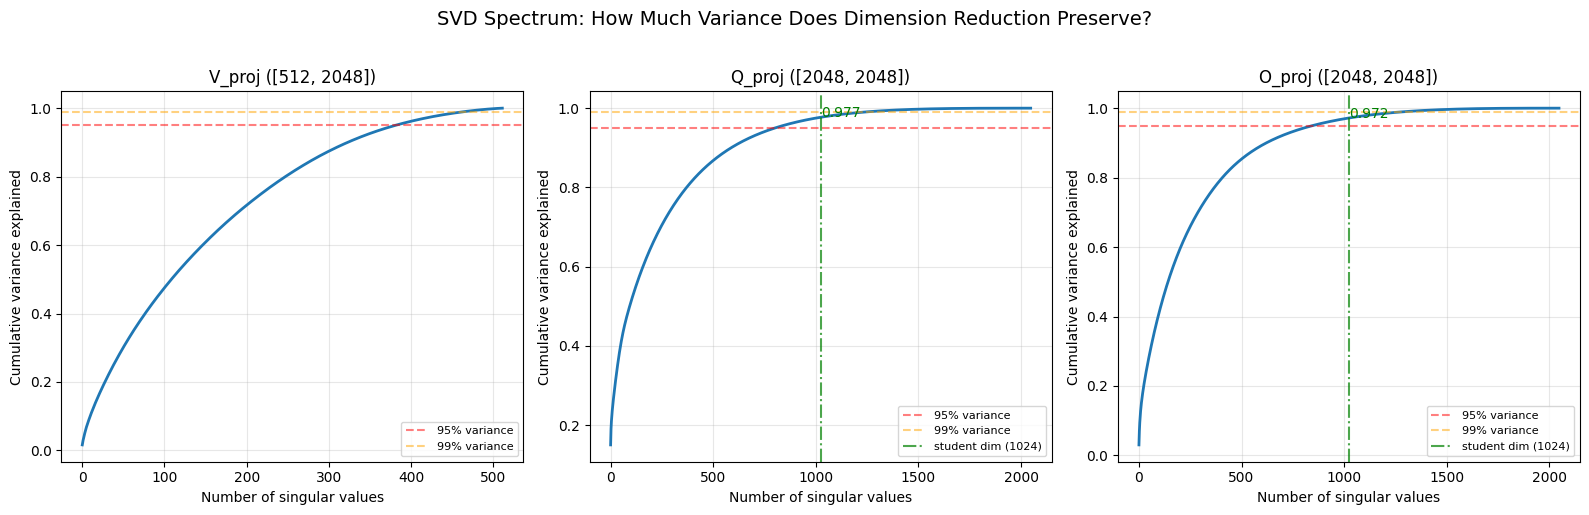

In [6]:
# Analyze SVD spectrum of teacher weight matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, proj_name) in zip(axes, [
    ("V_proj", "v_proj"), ("Q_proj", "q_proj"), ("O_proj", "o_proj")
]):
    W = getattr(attn_0, proj_name).weight.data.float().cpu()
    _, S, _ = torch.linalg.svd(W, full_matrices=False)
    S = S.numpy()
    
    # Cumulative variance explained
    var_explained = np.cumsum(S**2) / np.sum(S**2)
    
    ax.plot(var_explained, linewidth=2)
    ax.axhline(y=0.95, color="red", linestyle="--", alpha=0.5, label="95% variance")
    ax.axhline(y=0.99, color="orange", linestyle="--", alpha=0.5, label="99% variance")
    
    # Mark where student dim falls
    student_dim = min(student_cfg.d_model, len(S))
    if student_dim < len(S):
        ax.axvline(x=student_dim, color="green", linestyle="-.", alpha=0.7,
                   label=f"student dim ({student_dim})")
        var_at_student = var_explained[student_dim - 1]
        ax.annotate(f"{var_at_student:.3f}", (student_dim, var_at_student),
                   fontsize=10, color="green")
    
    ax.set_xlabel("Number of singular values")
    ax.set_ylabel("Cumulative variance explained")
    ax.set_title(f"{name} ({list(W.shape)})")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("SVD Spectrum: How Much Variance Does Dimension Reduction Preserve?", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../results/svd_variance_explained.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. FFN -> MoE Conversion: Replicate vs SVD Split

Compare the two FFN-to-MoE strategies. Do replicated experts start similar and diverge? Does SVD split capture different "specializations"?


replicate -- Expert pairwise CKA (w1):
  Expert 0 vs 1: 0.8258
  Expert 0 vs 2: 0.8258
  Expert 0 vs 3: 0.8260
  Expert 1 vs 2: 0.8257
  Expert 1 vs 3: 0.8256
  Expert 2 vs 3: 0.8261
  Mean: 0.8258



svd_split -- Expert pairwise CKA (w1):
  Expert 0 vs 1: 0.0953
  Expert 0 vs 2: 0.0947
  Expert 0 vs 3: 0.0933
  Expert 1 vs 2: 0.0995
  Expert 1 vs 3: 0.0967
  Expert 2 vs 3: 0.0974
  Mean: 0.0962


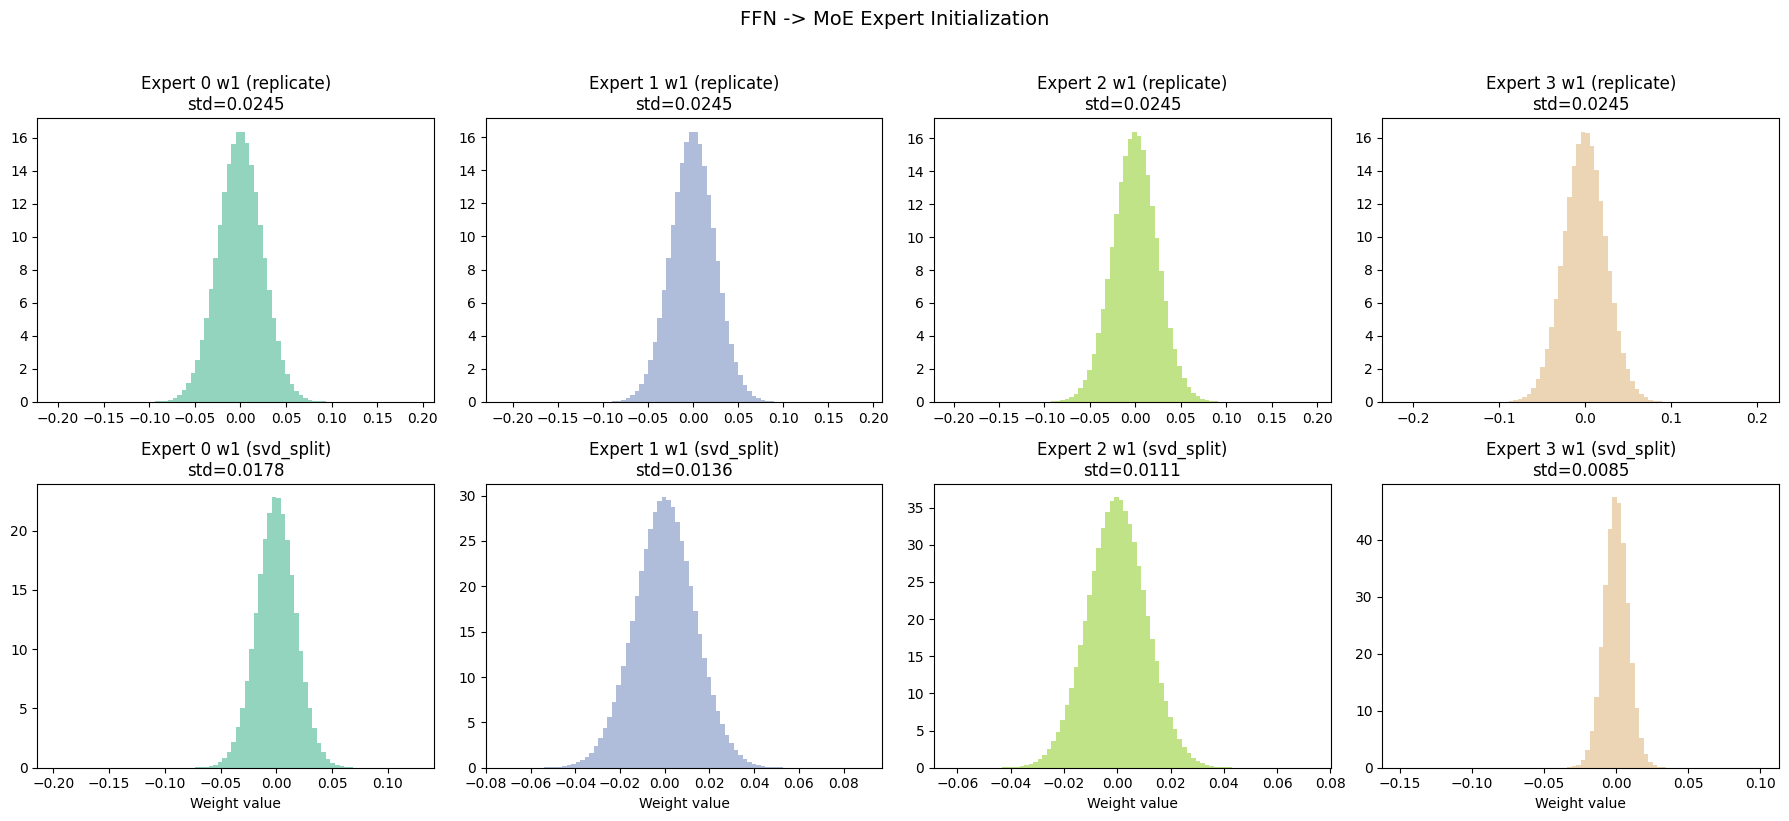


Replicate: experts start near-identical (high CKA), diversify during training
SVD split: experts start different (low CKA), each captures distinct FFN components


In [7]:
# Compare replicate vs svd_split
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for row, strategy in enumerate(["replicate", "svd_split"]):
    moe_block = SparseMoELayer(student_cfg)
    cfg_conv = ConversionConfig(strategy="weight_map", ffn_to_moe=strategy)
    metrics = convert_ffn_to_moe(mlp_0, moe_block, cfg_conv, layer_idx=0)
    
    for i, expert in enumerate(moe_block.experts):
        ax = axes[row, i]
        w1_vals = expert.w1.weight.data.float().cpu().flatten().numpy()
        ax.hist(w1_vals, bins=80, alpha=0.7, density=True,
                color=plt.cm.Set2(i / 4))
        ax.set_title(f"Expert {i} w1 ({strategy})\nstd={w1_vals.std():.4f}")
        if row == 1:
            ax.set_xlabel("Weight value")

    # Measure pairwise CKA between expert weight matrices
    expert_ckas = []
    for i in range(4):
        for j in range(i + 1, 4):
            w_i = moe_block.experts[i].w1.weight.data.float().cpu()
            w_j = moe_block.experts[j].w1.weight.data.float().cpu()
            cka = linear_cka(w_i, w_j).item()
            expert_ckas.append((i, j, cka))
    
    mean_cka = np.mean([c for _, _, c in expert_ckas])
    print(f"\n{strategy} -- Expert pairwise CKA (w1):")
    for i, j, c in expert_ckas:
        print(f"  Expert {i} vs {j}: {c:.4f}")
    print(f"  Mean: {mean_cka:.4f}")

plt.suptitle("FFN -> MoE Expert Initialization", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../results/moe_expert_init.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nReplicate: experts start near-identical (high CKA), diversify during training")
print("SVD split: experts start different (low CKA), each captures distinct FFN components")

## 7. Forward Pass Comparison

Run the same input through teacher attention and converted student SSM. Compare output distributions and measure CKA between the outputs.

In [8]:
# Compare teacher and student outputs using full model forward + hooks
from aya_distill.distill.hooks import ActivationStore, register_teacher_hooks

test_prompts = [
    "Explain gravity simply.",
    "Explica la gravedad.",
]

# Use hooks to capture layer-0 attention output from full model pass
store = ActivationStore(detach=True, device="cpu")
register_teacher_hooks(model, store, layer_indices=[0], hook_attention=True, hook_ffn=False)

for prompt in test_prompts:
    store.clear()
    with torch.no_grad():
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=32)
        _ = model(**inputs)
    
    acts = store.collect()
    t_key = list(acts.keys())[0]
    t_flat = acts[t_key][:, :student_cfg.d_model]  # project to student dim
    
    # Student SSM on same-dim input
    s_input = t_flat.unsqueeze(0).float()
    ssm_block.eval()
    ssm_block.float()
    student_out = ssm_block(s_input)
    s_flat = student_out.detach().reshape(-1, student_cfg.d_model)
    
    cka_score = linear_cka(t_flat, s_flat).item()
    cos_sim = torch.nn.functional.cosine_similarity(
        t_flat.mean(0, keepdim=True),
        s_flat.mean(0, keepdim=True),
    ).item()
    
    print(f"Prompt: {prompt[:40]:40s} | CKA={cka_score:.4f} | cos_sim={cos_sim:.4f}")

store.remove_hooks()
print("\nNote: CKA after weight_map only (no refinement). Hybrid strategy will improve this.")

Prompt: Explain gravity simply.                  | CKA=0.8744 | cos_sim=0.7610


Prompt: Explica la gravedad.                     | CKA=0.5770 | cos_sim=0.8598

Note: CKA after weight_map only (no refinement). Hybrid strategy will improve this.


## 8. Multi-Layer Conversion Sweep

Convert multiple teacher layers and track CKA across the network depth. Does conversion quality vary by layer position?

Sweeping 9 layers out of 36: [0, 4, 8, 12, 16, 20, 24, 28, 32]


  Layer  0: energy_ratio=0.7055, in_proj_std=0.0306


  Layer  4: energy_ratio=0.7062, in_proj_std=0.0261


  Layer  8: energy_ratio=0.7075, in_proj_std=0.0251


  Layer 12: energy_ratio=0.7077, in_proj_std=0.0268


  Layer 16: energy_ratio=0.7062, in_proj_std=0.0284


  Layer 20: energy_ratio=0.7066, in_proj_std=0.0266


  Layer 24: energy_ratio=0.7077, in_proj_std=0.0258


  Layer 28: energy_ratio=0.7123, in_proj_std=0.0245


  Layer 32: energy_ratio=0.7092, in_proj_std=0.0256


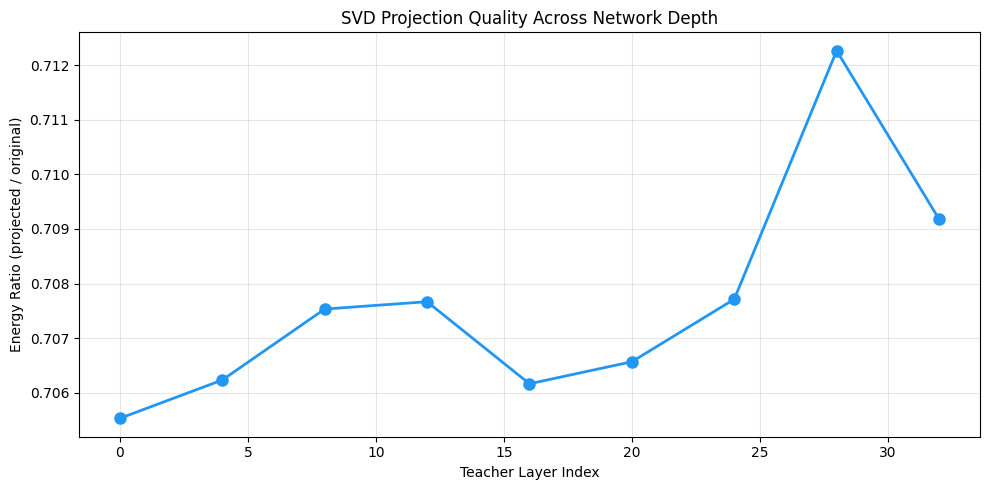

In [9]:
# Convert attention from every 4th teacher layer, measure weight-level statistics
n_teacher_layers = len(teacher_layers)
layer_indices = list(range(0, n_teacher_layers, max(1, n_teacher_layers // 8)))
layer_stats = []

print(f"Sweeping {len(layer_indices)} layers out of {n_teacher_layers}: {layer_indices}")

for t_idx in layer_indices:
    attn = teacher_layers[t_idx].self_attn
    ssm = SSMBlock(student_cfg)
    
    cfg_conv = ConversionConfig(strategy="weight_map", a_init="exponential_decay")
    metrics = convert_attention_to_ssm(attn, ssm, cfg_conv, layer_idx=t_idx)
    
    # Measure how well the SVD projection preserved the weight structure
    # Compare teacher V_proj to student in_proj (first half)
    v_orig = attn.v_proj.weight.data.float().cpu()
    in_proj_half = ssm.in_proj.weight.data[:ssm.d_inner].float().cpu()
    
    # Frobenius norm ratio (how much energy was preserved)
    proj_energy = torch.norm(in_proj_half).item()
    orig_energy = torch.norm(v_orig).item()
    
    layer_stats.append({
        "teacher_layer": t_idx,
        "energy_ratio": proj_energy / orig_energy if orig_energy > 0 else 0,
        "in_proj_std": ssm.in_proj.weight.data.std().item(),
        "out_proj_std": ssm.out_proj.weight.data.std().item(),
    })
    print(f"  Layer {t_idx:2d}: energy_ratio={layer_stats[-1]['energy_ratio']:.4f}, "
          f"in_proj_std={layer_stats[-1]['in_proj_std']:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
xs = [s["teacher_layer"] for s in layer_stats]
ys = [s["energy_ratio"] for s in layer_stats]
ax.plot(xs, ys, "o-", linewidth=2, markersize=8, color="#2196F3")
ax.set_xlabel("Teacher Layer Index")
ax.set_ylabel("Energy Ratio (projected / original)")
ax.set_title("SVD Projection Quality Across Network Depth")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../results/conversion_by_depth.png", dpi=150, bbox_inches="tight")
plt.show()

## Key Findings

1. **SVD projection** preserves most of the weight energy when projecting from 2048->1024 dimensions
2. **A_log initialization** with exponential decay creates a range of memory horizons (local to global attention)
3. **Replicate strategy** starts experts near-identical -- relies on training to specialize
4. **SVD split strategy** starts experts different -- may converge faster but risks losing coherence
5. **Weight-map only CKA** is a starting point -- hybrid strategy (+ refinement) should push it higher

**Next steps**: Run full model conversion (`scripts/run_conversion.py`) and monitor per-layer CKA throughout distillation stages.